# <center>Data Cleaning and Feature Engineering Guide</center>

## <center>Overview</center>
This guide outlines the systematic approach to prepare the airport operations dataset for machine learning modeling. Follow these steps sequentially to ensure data quality and create meaningful features that will improve model performance.

---

## <center>Prerequisites</center>

Before starting, ensure you have:
- The raw dataset loaded into your working environment
- Understanding of the 29 original features
- Familiarity with the EDA findings (17,545 records, date range 2019-2021)

---

## <center>Phase 1: Data Cleaning ✅ </center>

### <center>Step 1: Remove Unnecessary Columns ✅ </center>

**Columns to remove:** `Date`, `Heavy_Flow`, `Continuous_Flows`, `line_type`, `end_time`

**Rationale:**
- **Date**: Redundant because temporal information will be extracted into separate features
- **Heavy_Flow**: Sparse binary flag identified in EDA with limited predictive value
- **Continuous_Flows**: Contains >90% missing data, making it unreliable for modeling
- **line_type**: Provides limited variance or contains redundant information already captured elsewhere
- **end_time**: Will be used temporarily for feature engineering, then removed

**Expected outcome:** Dataset reduced from 29 to 24 features

---

### <center>Step 2: Remove Duplicate Rows ✅ </center>

**Action:** Identify and remove the duplicated rows found during EDA

**Rationale:** Even a single duplicate can introduce bias in model training and validation, particularly in small subsets of data

**Verification:** After removal, confirm dataset has 16,098 records

---

### <center>Step 3: Encode the `queue_agent` Column ✅ </center>

**Action:** Transform the `queue_agent` column from text/null format to binary numeric

**Encoding rule:**
- Replace 'X' with 1 (agent present)
- Replace null/NaN values with 0 (no agent)

**Rationale:** Machine learning algorithms require numeric inputs. This binary encoding preserves the information while making it model-compatible

**Optional:** Convert to boolean data type for memory efficiency

---

### <center>Step 4: Encode Additional Binary Flag Columns ✅ </center>

**Columns to encode:** `pax_left`, `flight_cancelled`, `carousell_stopped`

**Encoding rule (same as Step 3):**
- 'X' → 1 (event occurred)
- null/NaN → 0 (event did not occur)

**Rationale:** These sparse binary indicators represent important operational events. Converting them to numeric format ensures they can be used as features while maintaining their interpretability

**Expected outcome:** Four boolean/binary columns ready for modeling

---

## <center>Phase 2: Feature Engineering ✅ </center>

### <center>Step 5: Create Time Period Categories ✅ </center>

**Action:** Create a new categorical column called `time_period` based on the `start_time` column

**Time period definitions:**
- **Early Morning**: 00:00 - 05:59
- **Morning**: 06:00 - 11:59  
- **Afternoon**: 12:00 - 17:59
- **Evening**: 18:00 - 23:59

**Rationale:** 
- Airport operations vary significantly by time of day
- Passenger volumes, staffing levels, and processing times follow clear temporal patterns
- This categorical feature captures these patterns more effectively than raw timestamps

**Implementation:** Extract the hour component from `start_time` and map it to the appropriate category

---

### <center>Step 6: Apply One-Hot Encoding to Categorical Variables ✅ </center>

**Columns to encode:** `Sector`, `Period_of_Day` and `Airline`

**Sector encoding:**
- Original: 2 categories (Domestic, International)
- After encoding: 1 binary column (use drop_first to avoid redundancy)
  - Example: `Sector_International` where 1 = International, 0 = Domestic

**Airline encoding:**
- Original: 13 airline categories
- After encoding: 12 binary columns (use drop_first to avoid multicollinearity)
  - Example: `Airline_2`, `Airline_3`, etc.

**Rationale:**
- Most ML algorithms cannot directly process categorical text data
- One-hot encoding creates binary features for each category
- Dropping the first category prevents the "dummy variable trap" (perfect multicollinearity)

**Expected outcome:** Replace 2 categorical columns with 13 binary columns (1 for Sector + 12 for Airlines)

---

### <center>Step 7: Calculate Event Duration Features ✅ </center>

**Action:** Create two new duration features measured in minutes

**Duration 1 - Line Duration:**
- Calculate the time difference between `Start_Line` and `End_Line`
- Name the new column: `line_duration_min`
- Represents: How long passengers spent in the queue

**Duration 2 - Service Duration:**
- Calculate the time difference between `Service_Start` and `Service_End`
- Name the new column: `service_duration_min`
- Represents: How long the actual service/processing took

**Rationale:**
- Duration metrics are more meaningful than raw timestamps for prediction
- They capture operational efficiency and resource utilization patterns
- Shorter durations may indicate better performance or adequate staffing

**Important:** Convert results to minutes and round to 2 decimal places for consistency

---

### <center>Step 8: Drop Timestamp Columns After Feature Creation ✅ </center>

**Columns to remove:** `Start_Line`, `End_Line`, `Service_Start`, `Service_End`

**Rationale:**
- These raw timestamp columns have been transformed into meaningful duration features
- Keeping them would add unnecessary dimensionality without additional predictive value
- Raw timestamps can cause data leakage in time-series predictions

**Expected outcome:** Four columns removed, replaced by two engineered duration features

---

### <center>Step 9: Calculate Total Checked Bags ✅ </center>

**Action:** Create a new column called `total_checked_bags`

**Calculation:** Sum of `Luggage_In` - `Luggage_Out`

**Rationale:**
- Provides an aggregate view of baggage handling volume
- The strong correlation (0.769) between Luggage_In and Luggage_Out suggests they represent related aspects of the same process
- Total bags can be a better predictor of resource needs than individual components

**Note:** Keep the original `Luggage_In` and `Luggage_Out` columns as they may still provide value independently

---

### <center>Step 10: Drop Year Column ✅ </center>

**Action:** Remove the `Year` column from the dataset

**Rationale:**
- Year information is already captured through other temporal patterns in the data
- Keeping Year as a single numeric feature may introduce unintended temporal bias
- The dramatic variation between years (2020 COVID impact) might be better handled through specific indicators
- Alternative approaches (like pandemic flags) can capture the 2020 anomaly more explicitly

**Consideration:** If you created a pandemic indicator in a later step, Year becomes redundant

---

## <center>Phase 3: Outlier Detection and Handling ✅ </center>

### <center>Step 11: Check and Remove Outliers ✅ </center>

**Action:** Systematically identify and handle extreme values in numerical columns

**Target columns for outlier analysis:**
- `Pax_In_Line` (EDA showed max=65, mean=4.2)
- `PAX_Served` (max=12, mean=1.8)
- `Counters` (max=15, mean=5.4)
- `Luggage_In` (max=25, mean=3.0)
- `Luggage_Out` (max=15, mean=1.7)

**Detection method - IQR (Interquartile Range):**
1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
2. Calculate IQR = Q3 - Q1
3. Define outlier bounds:
   - Lower bound = Q1 - 1.5 × IQR
   - Upper bound = Q3 + 1.5 × IQR
4. Flag values outside these bounds

**Handling strategy - Choose based on context:**

**Option A - Remove outliers:**
- Best for: Clear data entry errors or impossible values
- Caution: Some "outliers" may represent legitimate peak events (holiday travel, special events)
- Recommendation: Only remove if outliers represent <5% of data AND seem invalid

**Option B - Cap outliers (Winsorization):**
- Best for: Legitimate extreme values that could skew models
- Method: Replace values beyond 1st/99th percentiles with the percentile values
- Preserves data volume while reducing extreme influence

**Option C - Keep and flag:**
- Best for: Peak events that are real and important
- Method: Create binary indicators like `is_peak_volume`
- Allows models to learn these patterns separately

**Important considerations:**
- Airport operations naturally have peak periods (holidays, connecting flights)
- Values like 65 passengers in line or 25 pieces of luggage might be real surge events
- Investigate outliers before removing—look for patterns by date, airline, or sector
- Document your decision and reasoning for reproducibility

---

## <center>Phase 4: Final Validation</center>

### <center>Step 14: Comprehensive Data Quality Checks</center>

**Action:** Perform final verification before proceeding to modeling

**Checklist:**

**1. Missing Values Audit:**
- Check every column for null/NaN values
- Verify that all binary encodings were successful
- Confirm no unexpected missing data was introduced during transformations

**2. Data Type Verification:**
- Numeric columns are int or float
- Binary flags are boolean or int (0/1)
- One-hot encoded columns are int (0/1)
- No unexpected object/string types remain

**3. Shape Validation:**
- Count final number of rows
- Count final number of columns
- Compare to expected dimensions based on transformations

**4. Duplicate Check:**
- Verify no duplicates remain
- Especially important after all transformations

**5. Value Range Validation:**
- Confirm all values are within expected ranges
- Binary columns only contain 0 and 1
- Negative values only appear where logically valid
- Check for any infinite values

**6. Consistency Checks:**
- Duration features are positive (end time > start time)
- Total_checked_bags = Luggage_In - Luggage_Out
- Counter counts are reasonable (typically 1-15)

**7. Statistical Sanity Checks:**
- Recalculate basic statistics (mean, median, std)
- Compare to original EDA to ensure transformations didn't corrupt data
- Verify distributions still make operational sense
- Check for multicolinearity in the features

**Expected outcome:** A validation report confirming the dataset is clean, consistent, and ready for modeling

---

## <center>Save the Cleaned Dataset</center>

**Action:** Export the final cleaned and engineered dataset

**File format recommendations:**
- **CSV**: Universal compatibility, human-readable
- **Parquet**: Better performance, preserves data types, smaller file size

**Naming convention:** Use descriptive names with version/date
- Example: `airport_data_cleaned_v1_2026-01-28.csv`

**Documentation:** Save a summary file alongside your data containing:
- Original dataset shape and final shape
- List of all transformations applied
- Outlier handling decisions
- Number of records removed and reasons
- Date of processing

**Backup:** Keep original raw data untouched in separate location

---

## <center>Summary of Transformations</center>

### Columns Removed (9 total):
1. Date
2. Heavy_Flow
3. Continuous_Flows
4. line_type
5. end_time
6. Start_Line
7. End_Line
8. Service_Start
9. Service_End
10. Year

### Columns Encoded (4 total):
1. queue_agent (X → 1, null → 0)
2. pax_left (X → 1, null → 0)
3. flight_cancelled (X → 1, null → 0)
4. carousell_stopped (X → 1, null → 0)

### Columns One-Hot Encoded:
1. Sector
2. Airline

### New Features Created (4 total):
1. time_period (4 categories: Early_Morning, Morning, Afternoon, Evening)
2. line_duration (calculated from Start_Line and End_Line)
3. service_duration (calculated from Service_Start and Service_End)
4. total_checked_bags (sum of Luggage_In and Luggage_Out)
5. total_time (sum of line_duration and service duration)

### Data Quality Actions:
- Removed duplicated row
- Handled outliers in 3 numerical columns

### Final Dataset Characteristics:
- **Features**: Approximately 35-40 (depending on encoding choices)
- **Memory**: Reduced through data type optimization
- **Quality**: Validated and model-ready

---

## <center>Next Steps After Cleaning</center>

Once data cleaning is complete, proceed with:

1. **Exploratory Analysis on Cleaned Data**
   - Verify distributions after transformations
   - Check correlations with new engineered features
   - Identify potential multicollinearity issues

2. **Feature Selection**
   - Use correlation analysis to identify redundant features
   - Apply feature importance techniques
   - Consider dimensionality reduction if needed

3. **Feature Scaling**
   - Apply StandardScaler for algorithms sensitive to scale
   - Or MinMaxScaler for bounded ranges
   - Don't scale one-hot encoded columns

4. **Train-Test Split**
   - Use temporal split to respect time ordering
   - Consider stratification by Sector or Airline
   - Typical split: 70-80% train, 20-30% test

5. **Model Development**
   - Start with baseline models (Linear Regression, Decision Trees)
   - Progress to ensemble methods (Random Forest, XGBoost)
   - Use cross-validation appropriate for time-series data

In [131]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [132]:
# Reading the dataset
df = pd.read_csv('../data/raw/checkin_queue_synthetic_2019_2025.csv')

In [133]:
df.head()

,Date,Start_Time,End_time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,...,Luggage_In,Luggage_Out,Line_Type,Queue_Agent,PAX_Left,Flight_Cancelled,Heavy_Flow,Continuous_Flow,Carousel_Stoped,Year
0,2019-11-01,16:00:00,17:00:00,Domestic,Ariline 2,16:37:39,16:50:30,13.0,16:50:33,16:57:49,...,10,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
1,2019-12-09,16:00:00,17:00:00,Domestic,Ariline 1,16:22:02,16:22:34,1.0,16:22:37,16:28:05,...,4,3.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2019
2,2019-07-05,22:00:00,23:00:00,International,Ariline 10,22:53:55,23:22:16,9.0,23:22:20,23:30:23,...,3,2.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2019
3,2019-05-11,11:00:00,12:00:00,Domestic,Ariline 1,11:18:01,11:34:07,10.0,11:34:10,11:37:11,...,4,3.0,BD,X,NaN,NaN,NaN,NaN,NaN,2019
4,2019-11-09,17:00:00,18:00:00,Domestic,Ariline 2,17:05:51,17:14:21,0.0,17:14:23,17:19:43,...,1,1.0,PM,X,NaN,NaN,NaN,NaN,NaN,2019


In [134]:
df.shape

(25168, 22)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25168 entries, 0 to 25167
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              25168 non-null  object 
 1   Start_Time        25168 non-null  object 
 2   End_time          25168 non-null  object 
 3   Sector            25168 non-null  object 
 4   Airline           25168 non-null  object 
 5   Start_Line        25168 non-null  object 
 6   End_line          25168 non-null  object 
 7   Pax_In_Line       25168 non-null  float64
 8   Service_Start     25168 non-null  object 
 9   Service_End       25168 non-null  object 
 10  PAX_Served        25168 non-null  int64  
 11  Counters          25168 non-null  int64  
 12  Luggage_In        25168 non-null  int64  
 13  Luggage_Out       25168 non-null  float64
 14  Line_Type         20870 non-null  object 
 15  Queue_Agent       10621 non-null  object 
 16  PAX_Left          307 non-null    object

In [136]:
# Removing Unnecessary Columns
columns_to_drop = ['Date', 'Heavy_Flow', 'End_time', 'Continuous_Flow', 'Line_Type', 'Year']
df.drop(columns=columns_to_drop, inplace=True)
df.head()

,Start_Time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,PAX_Served,Counters,Luggage_In,Luggage_Out,Queue_Agent,PAX_Left,Flight_Cancelled,Carousel_Stoped
0,16:00:00,Domestic,Ariline 2,16:37:39,16:50:30,13.0,16:50:33,16:57:49,4,3,10,7.0,NaN,NaN,NaN,NaN
1,16:00:00,Domestic,Ariline 1,16:22:02,16:22:34,1.0,16:22:37,16:28:05,3,6,4,3.0,NaN,NaN,NaN,NaN
2,22:00:00,International,Ariline 10,22:53:55,23:22:16,9.0,23:22:20,23:30:23,1,7,3,2.0,NaN,NaN,NaN,NaN
3,11:00:00,Domestic,Ariline 1,11:18:01,11:34:07,10.0,11:34:10,11:37:11,3,9,4,3.0,X,NaN,NaN,NaN
4,17:00:00,Domestic,Ariline 2,17:05:51,17:14:21,0.0,17:14:23,17:19:43,1,10,1,1.0,X,NaN,NaN,NaN


In [137]:
# removing duplicated rows
initial_shape = df.shape
df.drop_duplicates(inplace=True)
final_shape = df.shape
print(f"Initial shape: {initial_shape}, Final shape after removing duplicates: {final_shape}")

Initial shape: (25168, 16), Final shape after removing duplicates: (4141, 16)


In [138]:
# Creating a function to substitute null with 0 and "X" with 1
def clean_column(column):
    column.fillna(0, inplace=True)
    column.replace("X", 1, inplace=True)
    return column

In [139]:
# Applying the cleaning function to relevant columns
relevant_columns = ['Queue_Agent', 'PAX_Left', 'Flight_Cancelled','Carousel_Stoped']
for col in relevant_columns:
    df[col] = clean_column(df[col])

/var/folders/fv/sj80_n_s4xggzhpkj9595smm0000gn/T/ipykernel_2836/2490983523.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  column.replace("X", 1, inplace=True)


In [140]:
df.head()

,Start_Time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,PAX_Served,Counters,Luggage_In,Luggage_Out,Queue_Agent,PAX_Left,Flight_Cancelled,Carousel_Stoped
0,16:00:00,Domestic,Ariline 2,16:37:39,16:50:30,13.0,16:50:33,16:57:49,4,3,10,7.0,0,0,0,0
1,16:00:00,Domestic,Ariline 1,16:22:02,16:22:34,1.0,16:22:37,16:28:05,3,6,4,3.0,0,0,0,0
2,22:00:00,International,Ariline 10,22:53:55,23:22:16,9.0,23:22:20,23:30:23,1,7,3,2.0,0,0,0,0
3,11:00:00,Domestic,Ariline 1,11:18:01,11:34:07,10.0,11:34:10,11:37:11,3,9,4,3.0,1,0,0,0
4,17:00:00,Domestic,Ariline 2,17:05:51,17:14:21,0.0,17:14:23,17:19:43,1,10,1,1.0,1,0,0,0


In [141]:
# Creating a function to convert object columns to time
def convert_to_time(column):
    return pd.to_datetime(column, format='%H:%M:%S')

In [142]:
# Applying the convertion function to relevant columns
time_columns = ['Start_Time', 'Start_Line', 'End_line', 'Service_Start', 'Service_End']
for col in time_columns:
    df[col] = convert_to_time(df[col])

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4141 entries, 0 to 24914
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Start_Time        4141 non-null   datetime64[ns]
 1   Sector            4141 non-null   object        
 2   Airline           4141 non-null   object        
 3   Start_Line        4141 non-null   datetime64[ns]
 4   End_line          4141 non-null   datetime64[ns]
 5   Pax_In_Line       4141 non-null   float64       
 6   Service_Start     4141 non-null   datetime64[ns]
 7   Service_End       4141 non-null   datetime64[ns]
 8   PAX_Served        4141 non-null   int64         
 9   Counters          4141 non-null   int64         
 10  Luggage_In        4141 non-null   int64         
 11  Luggage_Out       4141 non-null   float64       
 12  Queue_Agent       4141 non-null   int64         
 13  PAX_Left          4141 non-null   int64         
 14  Flight_Cancelled  4141 non-n

In [144]:
df.head()

,Start_Time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,PAX_Served,Counters,Luggage_In,Luggage_Out,Queue_Agent,PAX_Left,Flight_Cancelled,Carousel_Stoped
0,1900-01-01 16:00:00,Domestic,Ariline 2,1900-01-01 16:37:39,1900-01-01 16:50:30,13.0,1900-01-01 16:50:33,1900-01-01 16:57:49,4,3,10,7.0,0,0,0,0
1,1900-01-01 16:00:00,Domestic,Ariline 1,1900-01-01 16:22:02,1900-01-01 16:22:34,1.0,1900-01-01 16:22:37,1900-01-01 16:28:05,3,6,4,3.0,0,0,0,0
2,1900-01-01 22:00:00,International,Ariline 10,1900-01-01 22:53:55,1900-01-01 23:22:16,9.0,1900-01-01 23:22:20,1900-01-01 23:30:23,1,7,3,2.0,0,0,0,0
3,1900-01-01 11:00:00,Domestic,Ariline 1,1900-01-01 11:18:01,1900-01-01 11:34:07,10.0,1900-01-01 11:34:10,1900-01-01 11:37:11,3,9,4,3.0,1,0,0,0
4,1900-01-01 17:00:00,Domestic,Ariline 2,1900-01-01 17:05:51,1900-01-01 17:14:21,0.0,1900-01-01 17:14:23,1900-01-01 17:19:43,1,10,1,1.0,1,0,0,0


In [145]:
# Creating a function to apply period_of day based on a column in datetime format
def apply_period_of_day(column):
    periods = []
    for time in column.dt.time:
        if time >= pd.to_datetime('05:00:00').time() and time < pd.to_datetime('12:00:00').time():
            periods.append('Morning')
        elif time >= pd.to_datetime('12:00:00').time() and time < pd.to_datetime('17:00:00').time():
            periods.append('Afternoon')
        elif time >= pd.to_datetime('17:00:00').time() and time < pd.to_datetime('21:00:00').time():
            periods.append('Evening')
        else:
            periods.append('Night')
    return periods

In [146]:
# Applying the time conversion function to Start_Time column
df['Period_of_Day'] = apply_period_of_day(df['Start_Time'])

In [147]:
df.head()

,Start_Time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,PAX_Served,Counters,Luggage_In,Luggage_Out,Queue_Agent,PAX_Left,Flight_Cancelled,Carousel_Stoped,Period_of_Day
0,1900-01-01 16:00:00,Domestic,Ariline 2,1900-01-01 16:37:39,1900-01-01 16:50:30,13.0,1900-01-01 16:50:33,1900-01-01 16:57:49,4,3,10,7.0,0,0,0,0,Afternoon
1,1900-01-01 16:00:00,Domestic,Ariline 1,1900-01-01 16:22:02,1900-01-01 16:22:34,1.0,1900-01-01 16:22:37,1900-01-01 16:28:05,3,6,4,3.0,0,0,0,0,Afternoon
2,1900-01-01 22:00:00,International,Ariline 10,1900-01-01 22:53:55,1900-01-01 23:22:16,9.0,1900-01-01 23:22:20,1900-01-01 23:30:23,1,7,3,2.0,0,0,0,0,Night
3,1900-01-01 11:00:00,Domestic,Ariline 1,1900-01-01 11:18:01,1900-01-01 11:34:07,10.0,1900-01-01 11:34:10,1900-01-01 11:37:11,3,9,4,3.0,1,0,0,0,Morning
4,1900-01-01 17:00:00,Domestic,Ariline 2,1900-01-01 17:05:51,1900-01-01 17:14:21,0.0,1900-01-01 17:14:23,1900-01-01 17:19:43,1,10,1,1.0,1,0,0,0,Evening


In [148]:
# Dropping Start_time column as it's no longer needed
df.drop(columns=['Start_Time'], inplace=True)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4141 entries, 0 to 24914
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Sector            4141 non-null   object        
 1   Airline           4141 non-null   object        
 2   Start_Line        4141 non-null   datetime64[ns]
 3   End_line          4141 non-null   datetime64[ns]
 4   Pax_In_Line       4141 non-null   float64       
 5   Service_Start     4141 non-null   datetime64[ns]
 6   Service_End       4141 non-null   datetime64[ns]
 7   PAX_Served        4141 non-null   int64         
 8   Counters          4141 non-null   int64         
 9   Luggage_In        4141 non-null   int64         
 10  Luggage_Out       4141 non-null   float64       
 11  Queue_Agent       4141 non-null   int64         
 12  PAX_Left          4141 non-null   int64         
 13  Flight_Cancelled  4141 non-null   int64         
 14  Carousel_Stoped   4141 non-n

In [150]:
# Creating a function to apply one-hot encoding to a categorical column
def one_hot_encode(column, df):
    dummies = pd.get_dummies(column, prefix=column.name, dtype=int, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[column.name], inplace=True)
    return df

In [151]:
# Applying one hot encoding to categorical columns
categorical_columns = ['Sector', 'Airline', 'Period_of_Day']
for col in categorical_columns:
    df = one_hot_encode(df[col], df)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4141 entries, 0 to 24914
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Start_Line             4141 non-null   datetime64[ns]
 1   End_line               4141 non-null   datetime64[ns]
 2   Pax_In_Line            4141 non-null   float64       
 3   Service_Start          4141 non-null   datetime64[ns]
 4   Service_End            4141 non-null   datetime64[ns]
 5   PAX_Served             4141 non-null   int64         
 6   Counters               4141 non-null   int64         
 7   Luggage_In             4141 non-null   int64         
 8   Luggage_Out            4141 non-null   float64       
 9   Queue_Agent            4141 non-null   int64         
 10  PAX_Left               4141 non-null   int64         
 11  Flight_Cancelled       4141 non-null   int64         
 12  Carousel_Stoped        4141 non-null   int64         
 13  Sector_

In [153]:
# Creating a function to calculate the duration of events in minutes
def calculate_duration(start_column, end_column):
    duration = (end_column - start_column).dt.total_seconds() / 60.0
    return duration

In [154]:
# Applying function to calculate durations and creating new columns
df['Line_Time'] = calculate_duration(df['Start_Line'], df['End_line'])
df['Service_Time'] = calculate_duration(df['Service_Start'], df['Service_End'])

In [155]:
df['Total_Time'] = df['Line_Time'] + df['Service_Time']

In [156]:
df.head()

,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,PAX_Served,Counters,Luggage_In,Luggage_Out,Queue_Agent,...,Airline_Ariline 6,Airline_Ariline 7,Airline_Ariline 8,Airline_Ariline 9,Period_of_Day_Evening,Period_of_Day_Morning,Period_of_Day_Night,Line_Time,Service_Time,Total_Time
0,1900-01-01 16:37:39,1900-01-01 16:50:30,13.0,1900-01-01 16:50:33,1900-01-01 16:57:49,4,3,10,7.0,0,...,0,0,0,0,0,0,0,12.850000,7.266667,20.116667
1,1900-01-01 16:22:02,1900-01-01 16:22:34,1.0,1900-01-01 16:22:37,1900-01-01 16:28:05,3,6,4,3.0,0,...,0,0,0,0,0,0,0,0.533333,5.466667,6.000000
2,1900-01-01 22:53:55,1900-01-01 23:22:16,9.0,1900-01-01 23:22:20,1900-01-01 23:30:23,1,7,3,2.0,0,...,0,0,0,0,0,0,1,28.350000,8.050000,36.400000
3,1900-01-01 11:18:01,1900-01-01 11:34:07,10.0,1900-01-01 11:34:10,1900-01-01 11:37:11,3,9,4,3.0,1,...,0,0,0,0,0,1,0,16.100000,3.016667,19.116667
4,1900-01-01 17:05:51,1900-01-01 17:14:21,0.0,1900-01-01 17:14:23,1900-01-01 17:19:43,1,10,1,1.0,1,...,0,0,0,0,1,0,0,8.500000,5.333333,13.833333


In [157]:
# Dropping datetime columns as they are no longer needed
datetime_columns = ['Start_Line', 'End_line', 'Service_Start', 'Service_End']
df.drop(columns=datetime_columns, inplace=True)

In [158]:
df['Total_Checked_Bags'] = df['Luggage_In'] - df['Luggage_Out']

In [159]:
# Dropping original time columns if not needed
df.drop(columns=['Luggage_In', 'Luggage_Out', 'Line_Time', 'Service_Time'], inplace=True)

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4141 entries, 0 to 24914
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pax_In_Line            4141 non-null   float64
 1   PAX_Served             4141 non-null   int64  
 2   Counters               4141 non-null   int64  
 3   Queue_Agent            4141 non-null   int64  
 4   PAX_Left               4141 non-null   int64  
 5   Flight_Cancelled       4141 non-null   int64  
 6   Carousel_Stoped        4141 non-null   int64  
 7   Sector_International   4141 non-null   int64  
 8   Airline_Ariline 10     4141 non-null   int64  
 9   Airline_Ariline 2      4141 non-null   int64  
 10  Airline_Ariline 3      4141 non-null   int64  
 11  Airline_Ariline 4      4141 non-null   int64  
 12  Airline_Ariline 5      4141 non-null   int64  
 13  Airline_Ariline 6      4141 non-null   int64  
 14  Airline_Ariline 7      4141 non-null   int64  
 15  Airline_

In [161]:
# Detection of outliers using IQR method
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

In [162]:
#Checking for outliers in a list of columns
columns_to_check = ['Total_Time']
for col in columns_to_check:
    outliers = detect_outliers_iqr(df[col])
    print(f"Outliers in {col}:")
    print(outliers)
    print("\n")

Outliers in Total_Time:
2        36.400000
19       38.200000
35       38.116667
48       45.650000
53       33.116667
           ...    
14643    32.083333
17431    35.866667
18496    39.933333
18699    31.016667
18923    81.733333
Name: Total_Time, Length: 280, dtype: float64




In [163]:
# Creating a function to remove outliers from the dataframe
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_cleaned

In [164]:
# Applying the functionto remove outliers from relevant columns
for col in columns_to_check:
    df = remove_outliers_iqr(df, col)

In [165]:
df.shape

(3861, 22)

In [166]:
df.describe()

,Pax_In_Line,PAX_Served,Counters,Queue_Agent,PAX_Left,Flight_Cancelled,Carousel_Stoped,Sector_International,Airline_Ariline 10,Airline_Ariline 2,...,Airline_Ariline 5,Airline_Ariline 6,Airline_Ariline 7,Airline_Ariline 8,Airline_Ariline 9,Period_of_Day_Evening,Period_of_Day_Morning,Period_of_Day_Night,Total_Time,Total_Checked_Bags
count,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,...,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000,3861.000000
mean,3.594406,1.747475,5.363377,0.423206,0.011396,0.002590,0.030821,0.260036,0.014504,0.219891,...,0.070448,0.066045,0.035483,0.015281,0.027713,0.253302,0.247863,0.042476,8.908236,1.260036
std,4.973683,0.987065,1.859521,0.494132,0.106156,0.050833,0.172855,0.438711,0.119572,0.414226,...,0.255934,0.248393,0.185021,0.122684,0.164171,0.434959,0.431828,0.201699,6.309578,1.042482
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.616667,0.000000
25%,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.016667,1.000000
50%,2.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.066667,1.000000
75%,5.000000,2.000000,7.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,12.333333,2.000000
max,55.000000,8.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,28.666667,7.000000


# Final Verifications

In [167]:
 # Checking for missing values
df.isnull().sum().sum()

0

In [168]:
# Checking for final data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3861 entries, 0 to 24914
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pax_In_Line            3861 non-null   float64
 1   PAX_Served             3861 non-null   int64  
 2   Counters               3861 non-null   int64  
 3   Queue_Agent            3861 non-null   int64  
 4   PAX_Left               3861 non-null   int64  
 5   Flight_Cancelled       3861 non-null   int64  
 6   Carousel_Stoped        3861 non-null   int64  
 7   Sector_International   3861 non-null   int64  
 8   Airline_Ariline 10     3861 non-null   int64  
 9   Airline_Ariline 2      3861 non-null   int64  
 10  Airline_Ariline 3      3861 non-null   int64  
 11  Airline_Ariline 4      3861 non-null   int64  
 12  Airline_Ariline 5      3861 non-null   int64  
 13  Airline_Ariline 6      3861 non-null   int64  
 14  Airline_Ariline 7      3861 non-null   int64  
 15  Airline_

In [169]:
# Shape validation
df.shape

(3861, 22)

In [170]:
# Checking for duplicated rows
df.duplicated().sum().sum()

5

In [171]:
# Dropping duplicated rows if any
df.drop_duplicates(inplace=True)

In [172]:
df.duplicated().sum().sum()

0

In [173]:
# Value range validation
df.describe()

,Pax_In_Line,PAX_Served,Counters,Queue_Agent,PAX_Left,Flight_Cancelled,Carousel_Stoped,Sector_International,Airline_Ariline 10,Airline_Ariline 2,...,Airline_Ariline 5,Airline_Ariline 6,Airline_Ariline 7,Airline_Ariline 8,Airline_Ariline 9,Period_of_Day_Evening,Period_of_Day_Morning,Period_of_Day_Night,Total_Time,Total_Checked_Bags
count,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,...,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000,3856.000000
mean,3.596214,1.748185,5.363330,0.422977,0.011411,0.002593,0.030861,0.260373,0.014523,0.219398,...,0.070539,0.066131,0.035529,0.015301,0.027749,0.253112,0.247925,0.042531,8.913045,1.260892
std,4.976164,0.987403,1.859945,0.494096,0.106224,0.050866,0.172963,0.438895,0.119648,0.413893,...,0.256087,0.248543,0.185137,0.122762,0.164274,0.434851,0.431864,0.201824,6.311406,1.042488
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.616667,0.000000
25%,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.016667,1.000000
50%,2.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.075000,1.000000
75%,5.000000,2.000000,7.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,12.337500,2.000000
max,55.000000,8.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,28.666667,7.000000


In [174]:
# Checking for negative values in all columns
(df < 0).sum().sum()

0

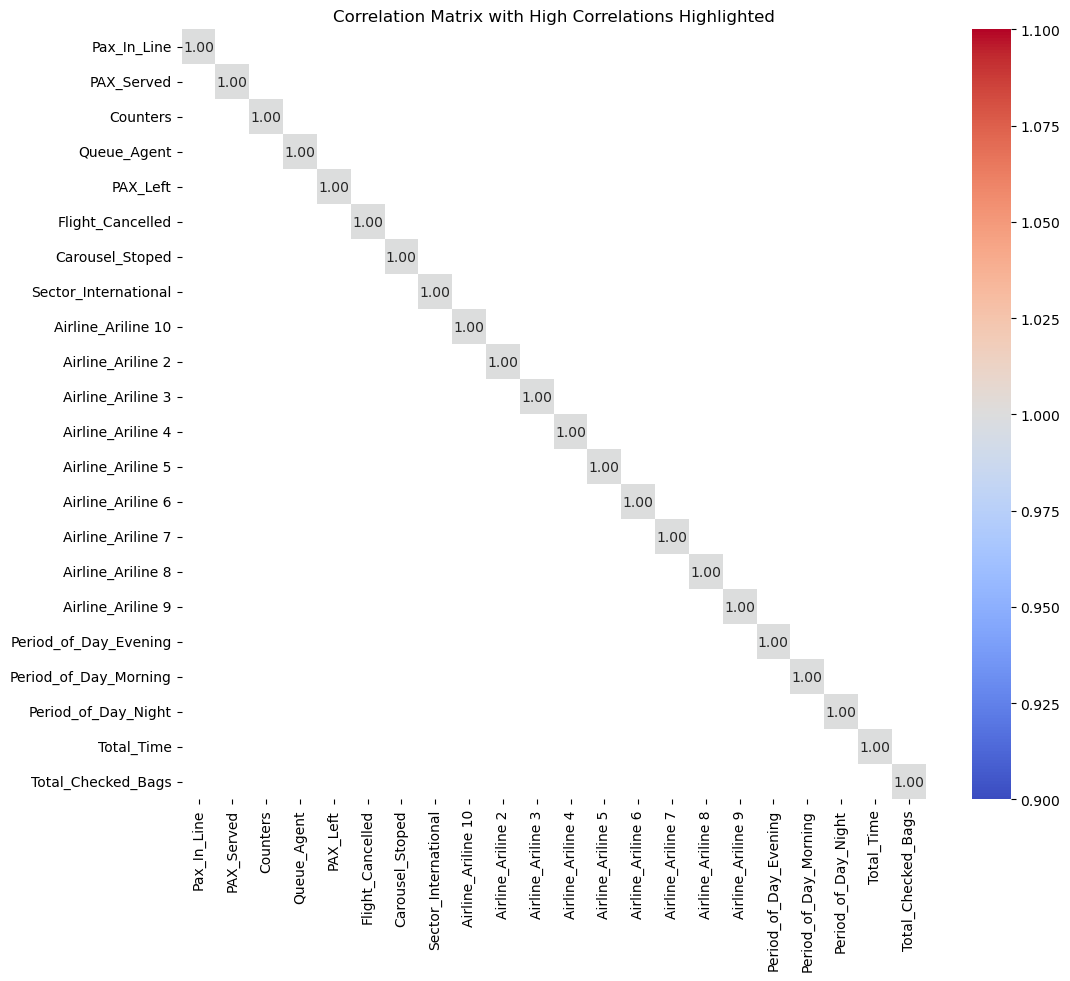

In [179]:
# Checking and ploting Multicolinearity greater than 0.8
corr_matrix = df.corr()
high_corr = corr_matrix.abs() > 0.7
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=~high_corr)
plt.title('Correlation Matrix with High Correlations Highlighted')
plt.show()

In [180]:
# checking for VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df.select_dtypes(include=[np.number])  # Selecting only numeric columns
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                  feature       VIF
0             Pax_In_Line  2.736221
1              PAX_Served  5.680720
2                Counters  6.760487
3             Queue_Agent  2.098859
4                PAX_Left  1.059131
5        Flight_Cancelled  1.045813
6         Carousel_Stoped  1.056278
7    Sector_International  6.004764
8      Airline_Ariline 10  1.939966
9       Airline_Ariline 2  1.983273
10      Airline_Ariline 3  1.861553
11      Airline_Ariline 4  2.795334
12      Airline_Ariline 5  1.191219
13      Airline_Ariline 6  2.858430
14      Airline_Ariline 7  1.963333
15      Airline_Ariline 8  1.042358
16      Airline_Ariline 9  1.851319
17  Period_of_Day_Evening  2.843321
18  Period_of_Day_Morning  1.580222
19    Period_of_Day_Night  2.228326
20             Total_Time  5.613272
21     Total_Checked_Bags  3.647998


In [181]:
# Saving the cleaned dataset
df.to_csv('../data/processed/checkin_queue_cleaned.csv', index=False)